# Infection Positivity Analysis for University Campus Health Surveillance Project 
# Author: Ari M.
# Description: Explores infection trends across diseases and demographic groups using the cleaned campus health dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option("display.max_columns", None)

## Load Cleaned Datasets

I will analyze infection trends using the cleaned datasets produced in the previous data cleaning.

Datasets:

• **patients_cleaned.csv** – demographic information  
• **tests_cleaned.csv** – diagnostic testing records  
• **vaccinations_cleaned.csv** – vaccination records

In [3]:
patients_path = "../data/cleaned/patients_cleaned.csv"
tests_path = "../data/cleaned/tests_cleaned.csv"
vaccinations_path = "../data/cleaned/vaccinations_cleaned.csv"

## Load the Data

Load the cleaned datasets and then I will confirm that they loaded successfully.

In [4]:
patients = pd.read_csv(patients_path)
tests = pd.read_csv(tests_path)
vaccinations = pd.read_csv(vaccinations_path)

print("Patient count:", len(patients))
print("Test count:", len(tests))
print("Vaccination count:", len(vaccinations))

Patient count: 7088
Test count: 25103
Vaccination count: 10073


### Observation

The dataset contains over 25,000 diagnostic test records and approximately 7,000 patients.

## Distribution of Tests by Disease

I want to understand how tests are distributed across diseases to provide context before calculating positivity rates.

In [5]:
tests["disease"].value_counts()

disease
Gonorrhea    5246
Influenza    5222
Norovirus    5184
Chlamydia    5179
COVID-19     4272
Name: count, dtype: int64

### Observation

The number of tests per disease appears relatively balanced.


## Population Composition

Next, I'll examine the distribution of patients by population group.

In [6]:
patients["staff_or_student_status"].value_counts()

staff_or_student_status
Student    5316
Staff      1772
Name: count, dtype: int64

### Observation

Students represent the majority of the population in the dataset.

In [7]:
vaccinations["vaccine_type"].value_counts()

vaccine_type
Influenza    5125
COVID-19     4948
Name: count, dtype: int64

### Observation

The dataset contains vaccination records for both COVID-19 and Influenza vaccines, which will allow me to explore vaccination coverage and potential relationships with infection trends.

## Identifying Positive Test Results

To make it easier to calculate positivity rates, I will create a Boolean column that identifies whether a test result was positive.

In [8]:
tests["is_positive"] = tests["test_result"] == "Positive"

tests.head()

,test_id,patient_id,disease,test_date,test_result,report_date,lab_source,is_positive
0,1,4046,Norovirus,2019-07-18,Negative,2019-07-20,Campus Lab,False
1,2,6291,Gonorrhea,2022-07-13,Negative,2022-07-15,Hospital Lab,False
2,3,6255,COVID-19,2020-01-25,Negative,2020-01-27,Campus Lab,False
3,4,1613,Chlamydia,2019-08-27,Negative,2019-08-29,Hospital Lab,False
4,5,7005,COVID-19,2020-05-23,Negative,2020-05-25,Hospital Lab,False


## Positivity Rate by Disease

The positivity rate measures the proportion of tests that return a positive result for a given disease.

In [9]:
positivity_rate = (
    tests.groupby("disease")["is_positive"]
    .mean()
    .sort_values(ascending=False)
)

positivity_rate

disease
Chlamydia    0.067001
Gonorrhea    0.035837
COVID-19     0.024345
Norovirus    0.022377
Influenza    0.020682
Name: is_positive, dtype: float64

### Observation

Chlamydia shows the highest positivity rate, followed by Gonorrhea.

Respiratory illnesses such as Influenza and Norovirus show lower positivity rates in comparison.

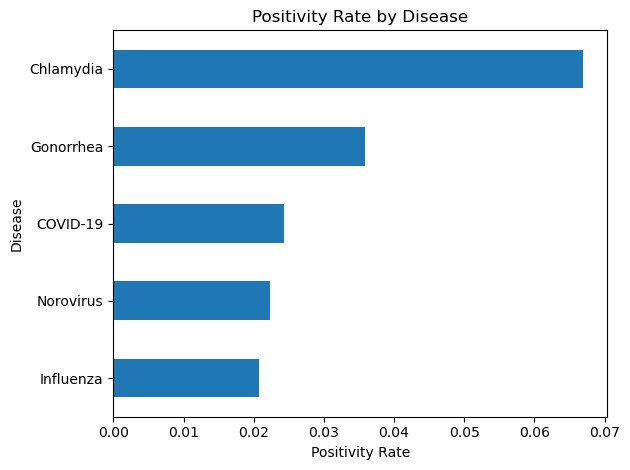

In [10]:
#To better understand how positivity varies across diseases, I’ll visualize these rates.
import matplotlib.pyplot as plt

# Plot positivity rate by disease
positivity_rate.sort_values().plot(kind="barh")

plt.title("Positivity Rate by Disease")
plt.xlabel("Positivity Rate")
plt.ylabel("Disease")

plt.tight_layout()
plt.show()

### Observation

Chlamydia and Gonorrhea show higher positivity rates compared to other diseases.

This suggests that, within this dataset, sexually transmitted infections have a higher likelihood of returning a positive result when tests are conducted.

## Create Age Groups

Grouping ages into categories will help me identify demographic patterns in infection risk.

In [11]:
bins = [17,20,25,35,50,65]
labels = ["18-20","21-25","26-35","36-50","51-65"]

patients["age_group"] = pd.cut(
    patients["age"],
    bins=bins,
    labels=labels
)

patients.head()

,patient_id,age,gender,staff_or_student_status,residence_type,pt_has_test_y_n,pt_has_vaccination_y_n,age_group
0,1,25,Female,Student,On-campus,Yes,No,21-25
1,2,25,Male,Student,Off-campus,Yes,No,21-25
2,3,23,Male,Student,On-campus,Yes,Yes,21-25
3,4,20,Male,Student,On-campus,Yes,Yes,18-20
4,5,25,Female,Student,Off-campus,Yes,No,21-25


## Merge Test and Patient Data

To analyze infection patterns across demographics, I merge testing records with patient demographic data using the patient_id.

In [12]:
tests_merged = tests.merge(
    patients,
    on="patient_id",
    how="left"
)

tests_merged.shape

(25103, 15)

In [13]:
tests_merged.head()

,test_id,patient_id,disease,test_date,test_result,report_date,lab_source,is_positive,age,gender,staff_or_student_status,residence_type,pt_has_test_y_n,pt_has_vaccination_y_n,age_group
0,1,4046,Norovirus,2019-07-18,Negative,2019-07-20,Campus Lab,False,18,Male,Student,On-campus,Yes,Yes,18-20
1,2,6291,Gonorrhea,2022-07-13,Negative,2022-07-15,Hospital Lab,False,24,Male,Student,On-campus,Yes,Yes,21-25
2,3,6255,COVID-19,2020-01-25,Negative,2020-01-27,Campus Lab,False,21,Male,Student,On-campus,Yes,Yes,21-25
3,4,1613,Chlamydia,2019-08-27,Negative,2019-08-29,Hospital Lab,False,23,Male,Student,Off-campus,Yes,Yes,21-25
4,5,7005,COVID-19,2020-05-23,Negative,2020-05-25,Hospital Lab,False,48,Female,Staff,Off-campus,Yes,Yes,36-50


### Observation

The merged dataset now includes both diagnostic test information and patient demographic attributes.

This combined dataset allows me to analyze infection trends across age groups and population types.

In [14]:
positive_cases = tests_merged[tests_merged["is_positive"]]

## Positive Cases by Age Group

In [15]:
cases_by_age = positive_cases.groupby("age_group", observed=False).size()

cases_by_age

age_group
18-20    261
21-25    418
26-35     47
36-50     66
51-65     71
dtype: int64

### Observation

The majority of positive cases occur in the 18–25 age range.

This result is expected because the dataset represents a university population where students are mostly within this age group.

In [16]:
# Positive cases by population
cases_by_status = positive_cases.groupby("staff_or_student_status").size()
cases_by_status

staff_or_student_status
Staff      184
Student    679
dtype: int64

In [17]:
# Overall positivity rate by population
population_positivity = tests_merged.groupby("staff_or_student_status")["is_positive"].mean()
population_positivity

staff_or_student_status
Staff      0.029257
Student    0.036090
Name: is_positive, dtype: float64

### Observation

Students account for the majority of positive cases, which is partially driven by the larger student population. 

Looking at the overall positivity rate by population shows the proportion of positive tests for each group, providing a clearer picture of infection risk.

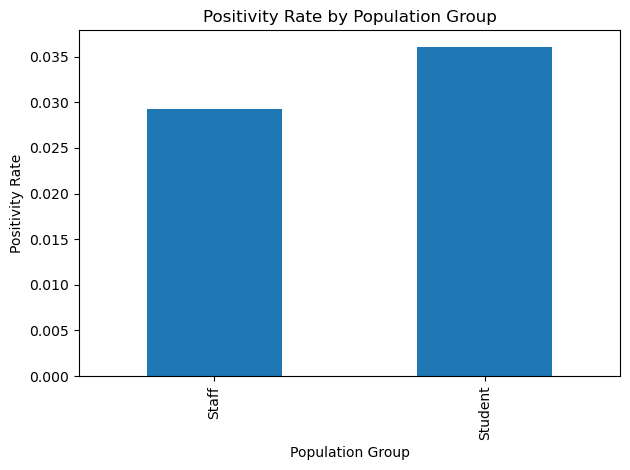

In [18]:
population_positivity.plot(kind="bar")

plt.title("Positivity Rate by Population Group")
plt.xlabel("Population Group")
plt.ylabel("Positivity Rate")

plt.tight_layout()
plt.show()

### Observation

Students show a slightly higher positivity rate compared to staff.

This may reflect differences in exposure patterns, such as living arrangements or social interactions.

However, the difference is relatively small, suggesting that the higher number of student cases is driven more by population size than by a large difference in risk.

## How Positivity Varies by Age and Population

In [19]:
positivity_by_age_status = (
    tests_merged
    .groupby(["age_group", "staff_or_student_status"], observed=False)["is_positive"]
    .mean()
    .unstack()
)

positivity_by_age_status

staff_or_student_status,Staff,Student
age_group,,
18-20,NaN,0.037997
21-25,NaN,0.034994
26-35,0.030500,NaN
36-50,0.027386,NaN
51-65,0.030368,NaN


In [20]:
positivity_by_age_status = (
    tests_merged
    .groupby(["age_group", "staff_or_student_status"], observed=True)["is_positive"]
    .mean()
    .unstack()
)

positivity_by_age_status = positivity_by_age_status.fillna(0)

positivity_by_age_status

staff_or_student_status,Staff,Student
age_group,,
18-20,0.000000,0.037997
21-25,0.000000,0.034994
26-35,0.030500,0.000000
36-50,0.027386,0.000000
51-65,0.030368,0.000000


In [21]:
# Saving positivity by age and population to support downstream visualization and dashboard development.
positivity_by_age_status.to_csv("../data/cleaned/positivity_by_age_population.csv")

### Note

I initially ran the calculation with `observed=False`, which included all possible age group and population combinations and resulted in NaN values where no data existed.  

I then reran it with `observed=True` and replaced NaN values with 0 for readability. These 0 values represent combinations that do not exist in the dataset, rather than true zero positivity rates.

### Observation

Younger age groups show positivity primarily among students, while older age groups show cases primarily among staff.

This makes sense as the majority of students are 18–25 years old, so I expect most positive cases in this age group.

This pattern reflects the demographic structure defined in the simulated dataset I created.

## Positivity Rate by Disease and Population

To better understand how infection risk differs across groups, I will break down positivity rates by both disease and population (students vs staff).

In [22]:
positivity_by_disease_population = (
    tests_merged
    .groupby(["disease", "staff_or_student_status"])["is_positive"]
    .mean()
    .unstack()
)

positivity_by_disease_population

staff_or_student_status,Staff,Student
disease,,
COVID-19,0.031050,0.022033
Chlamydia,0.042969,0.074891
Gonorrhea,0.020438,0.041280
Influenza,0.025498,0.019158
Norovirus,0.027153,0.020796


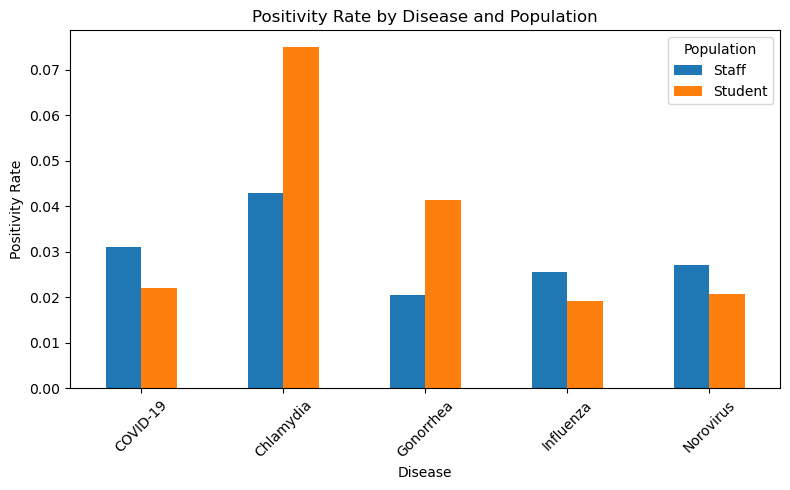

In [23]:
positivity_by_disease_population.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Positivity Rate by Disease and Population")
plt.xlabel("Disease")
plt.ylabel("Positivity Rate")

plt.xticks(rotation=45)
plt.legend(title="Population")

plt.tight_layout()
plt.show()

### Observation

Breaking down positivity rates by both disease and population shows that differences between students and staff are not the same across all diseases.

For example, sexually transmitted infections like Chlamydia and Gonorrhea appear to have higher positivity rates among students compared to staff. 

In contrast, respiratory illnesses such as COVID-19 and Influenza show smaller differences between the two groups.

This suggests that infection risk may depend more on the type of disease rather than just the population group alone.


In [24]:
# Saving positivity by age and population for downstream use
positivity_by_age_status.to_csv("../data/cleaned/positivity_by_age_population.csv")

## Save Analysis Results

I will export the positivity rate calculations for use in visualizations and dashboard that I will work on next.

In [25]:
# Saving the outputs for dashboard use
positivity_rate.to_csv("../data/cleaned/positivity_rate_by_disease.csv")
positivity_by_age_status.to_csv("../data/cleaned/positivity_by_age_population.csv")

print("Analysis saved successfully.")

Analysis saved successfully.


## Key Insights

Several patterns emerge from the analysis:

• Chlamydia has the highest positivity rate among the diseases analyzed  
• Most positive cases occur within the 18–25 age range  
• Students represent the majority of positive cases  
• However, comparing positivity rates shows that differences between students and staff are smaller than raw counts suggest  

These findings provide me with a foundation for further analysis and visualization in the next phase of the project.